# Proyek Klasifikasi Gambar: [CORN Leaf Diseases]
- **Nama:** [Muhammad Yazid Supriadi]
- **Email:** [yazidsupriadi1406@gmail.com]
- **ID Dicoding:** [
Muhammad Yazid Supriadi]

## Import Semua Packages/Library yang Digunakan

In [21]:
!pip install -q tensorflowjs
!pip install tensorflow==2.19.0 tensorflow-decision-forests==1.12.0

In [22]:
import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
import time
from PIL import Image as PILImage
from sklearn.metrics import confusion_matrix, classification_report


import kagglehub

import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import os
import shutil

import tensorflowjs as tfjs

# **Data Loading**

In [23]:
!pip install kagglehub

In [24]:
kagglehub.login()

In [25]:
!kaggle datasets download -d yusufmurtaza01/corn-leaf-diseases

Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/corn-leaf-diseases
License(s): CC0-1.0
corn-leaf-diseases.zip: Skipping, found more recently modified local copy (use --force to force download)


### Load Image Data

In [26]:
!unzip corn-leaf-diseases.zip

Archive:  corn-leaf-diseases.zip
replace corn/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace corn/images/train/pd_train_train_00020.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace corn/images/train/pd_train_train_00023.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: [n]o
error:  invalid response [[n]o]
replace corn/images/train/pd_train_train_00023.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N A


## Data Preparation

In [27]:
# menentukan path
path = '/content/corn'

### Data Preprocessing

In [28]:
yaml_path = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".yaml") or f.endswith(".yml"):
            yaml_path = os.path.join(root, f)
            break
    if yaml_path:
        break

print("dataset.yaml ditemukan di:", yaml_path)

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

dataset.yaml ditemukan di: /content/corn/data.yaml
{'path': '/kaggle/input/datasets/yusufmurtaza01/corn-leaf-diseases/corn', 'train': 'images/train', 'val': 'images/val', 'test': '', 'nc': 4, 'names': ['Corn__CommonRust', 'Corn__GrayLeafSpot', 'Corn__Healthy', 'Corn__NorthernLeafBlight']}


In [29]:

# names bisa berupa list atau dict, kita normalkan ke dict {id: nama}
names_raw = data_yaml["names"]
if isinstance(names_raw, list):
    id_to_name = {i: name for i, name in enumerate(names_raw)}
else:
    id_to_name = {int(k): v for k, v in names_raw.items()}

print("Kelas terdeteksi:", id_to_name)
NUM_CLASSES = len(id_to_name)

Kelas terdeteksi: {0: 'Corn__CommonRust', 1: 'Corn__GrayLeafSpot', 2: 'Corn__Healthy', 3: 'Corn__NorthernLeafBlight'}


In [30]:

images_train_dir = None
labels_train_dir = None
images_val_dir = None
labels_val_dir = None

for root, dirs, files in os.walk(path):
    norm_root = root.replace("\\", "/")
    if norm_root.endswith("images/train"):
        images_train_dir = root
    elif norm_root.endswith("images/val"):
        images_val_dir = root
    elif norm_root.endswith("labels/train"):
        labels_train_dir = root
    elif norm_root.endswith("labels/val"):
        labels_val_dir = root

print("images/train:", images_train_dir)
print("labels/train:", labels_train_dir)
print("images/val  :", images_val_dir)
print("labels/val  :", labels_val_dir)

images/train: /content/corn/images/train
labels/train: /content/corn/labels/train
images/val  : /content/corn/images/val
labels/val  : /content/corn/labels/val


In [31]:
combined_dir = "corn-leaf-image/dataset"
for cls_name in id_to_name.values():
    os.makedirs(os.path.join(combined_dir, cls_name), exist_ok=True)


def get_first_class_id(label_path):
    """Ambil class_id pertama dari file label YOLO (.txt)."""
    try:
        with open(label_path, "r") as f:
            line = f.readline().strip()
            if not line:
                return None
            return int(line.split()[0])
    except Exception:
        return None


def convert_split(images_dir, labels_dir):
    n_copied, n_skipped = 0, 0
    if images_dir is None or labels_dir is None:
        return n_copied, n_skipped

    for fname in os.listdir(images_dir):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        base_name = os.path.splitext(fname)[0]
        label_path = os.path.join(labels_dir, base_name + ".txt")

        if not os.path.exists(label_path):
            n_skipped += 1
            continue

        cls_id = get_first_class_id(label_path)
        if cls_id is None or cls_id not in id_to_name:
            n_skipped += 1
            continue

        cls_name = id_to_name[cls_id]
        src = os.path.join(images_dir, fname)
        dst = os.path.join(combined_dir, cls_name, fname)
        if not os.path.exists(dst):
            shutil.copy(src, dst)
        n_copied += 1

    return n_copied, n_skipped


copied_train, skipped_train = convert_split(images_train_dir, labels_train_dir)
copied_val, skipped_val = convert_split(images_val_dir, labels_val_dir)

print(f"Train -> disalin: {copied_train}, dilewati: {skipped_train}")
print(f"Val   -> disalin: {copied_val}, dilewati: {skipped_val}")

for cls_name in id_to_name.values():
    n_files = len(os.listdir(os.path.join(combined_dir, cls_name)))
    print(f"Kelas '{cls_name}': {n_files} gambar")

Train -> disalin: 3223, dilewati: 0
Val   -> disalin: 804, dilewati: 0
Kelas 'Corn__CommonRust': 1307 gambar
Kelas 'Corn__GrayLeafSpot': 580 gambar
Kelas 'Corn__Healthy': 1157 gambar
Kelas 'Corn__NorthernLeafBlight': 983 gambar


/tmp/ipykernel_43209/95830615.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df_dist, palette='viridis')


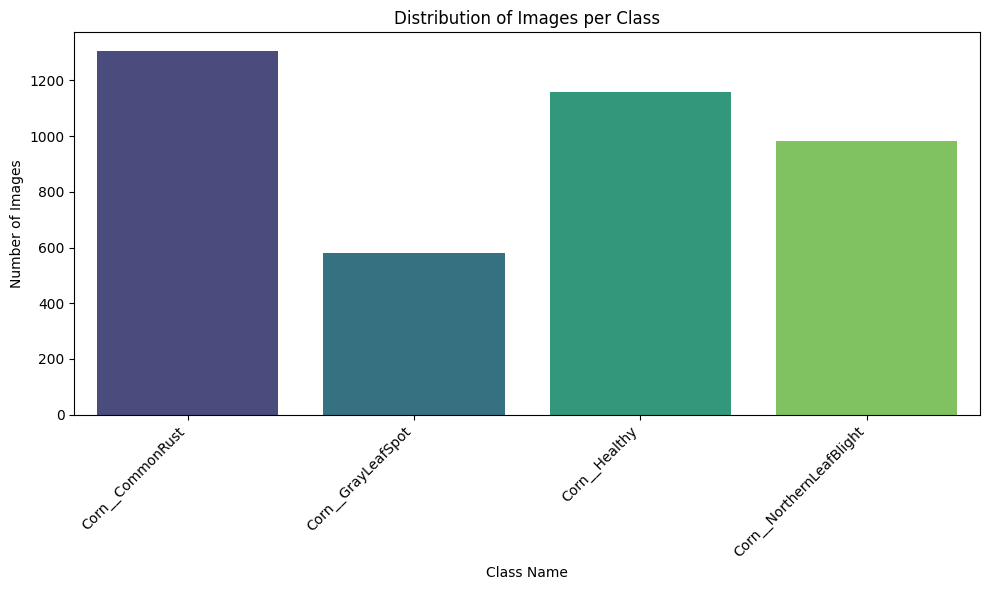

In [32]:
# data untuk dilakukan plot
class_names = list(id_to_name.values())
file_counts = []
for cls_name in class_names:
    n_files = len(os.listdir(os.path.join(combined_dir, cls_name)))
    file_counts.append(n_files)

df_dist = pd.DataFrame({
    'Class': class_names,
    'Count': file_counts
})

# tampilkan plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=df_dist, palette='viridis')
plt.title('Distribution of Images per Class')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Display Random Images per Class

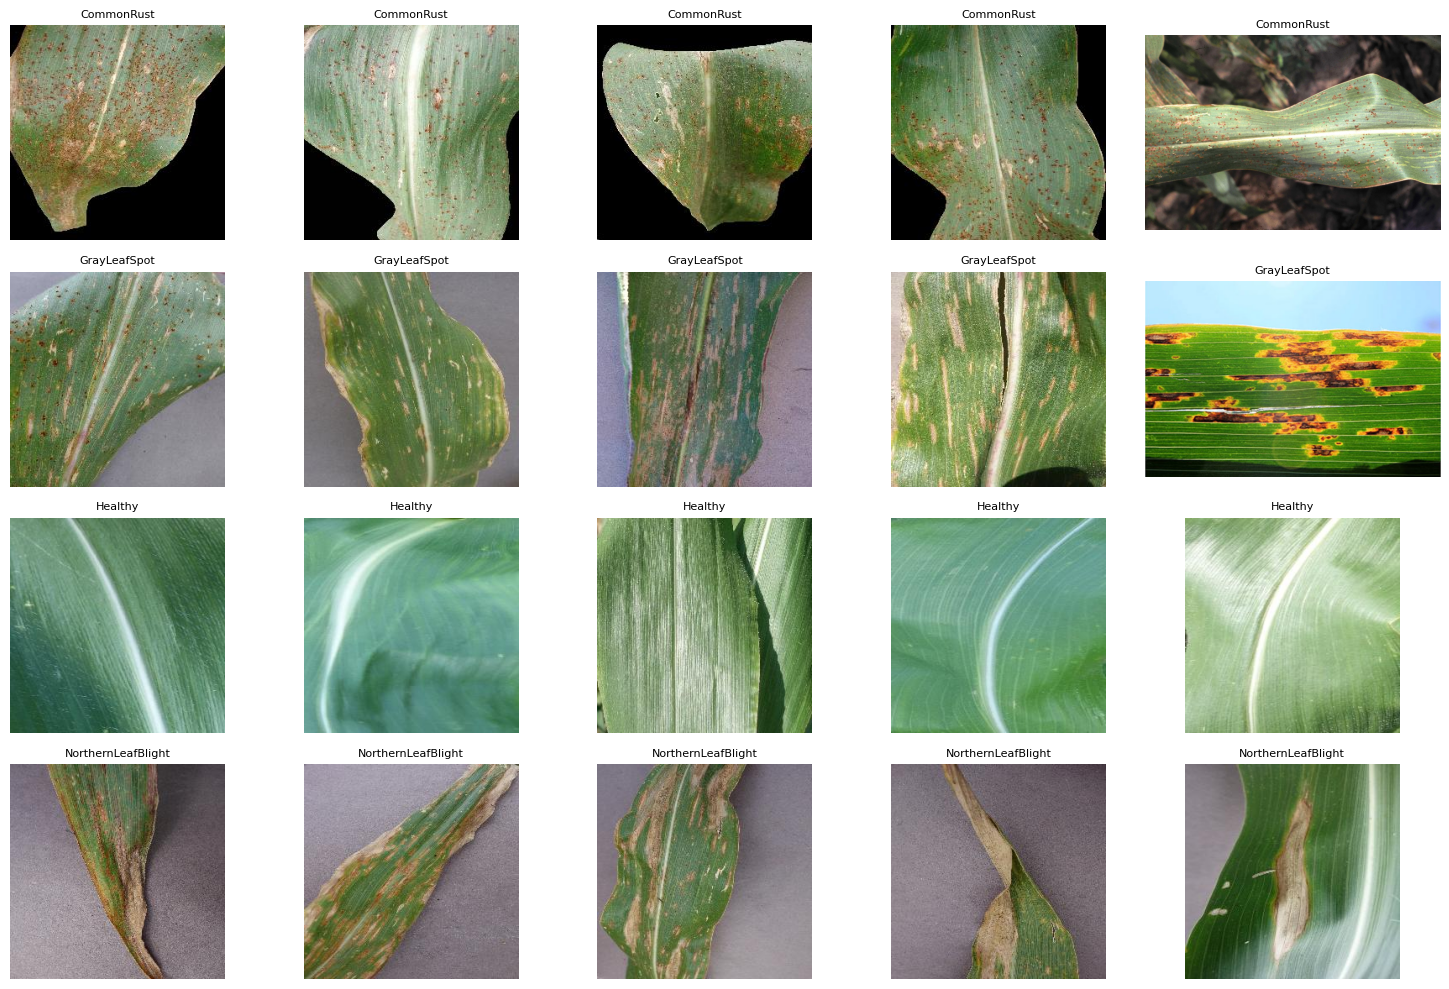

In [33]:
plt.figure(figsize=(15, 10))

num_images_to_display = 5

for i, cls_name in enumerate(id_to_name.values()):
    class_path = os.path.join(combined_dir, cls_name)
    all_images = os.listdir(class_path)

    # ambil random sampel tiap kelas
    sample_images = random.sample(all_images, min(num_images_to_display, len(all_images)))

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        #menampilkan plot image
        plt.subplot(len(id_to_name), num_images_to_display, i * num_images_to_display + j + 1)
        plt.imshow(img)
        plt.title(f"{cls_name.split('__')[-1].replace('Corn__', '')}", fontsize=8)
        plt.axis('off')

plt.tight_layout()
plt.show()

#### Split Dataset

In [34]:

split_base = "corn-leaf-image/split"
splits = ["train", "val", "test"]
for split in splits:
    for cls_name in id_to_name.values():
        os.makedirs(os.path.join(split_base, split, cls_name), exist_ok=True)

TRAIN_RATIO, VAL_RATIO = 0.70, 0.15  # sisanya 0.15 untuk test
random.seed(42)

for cls_name in id_to_name.values():
    cls_dir = os.path.join(combined_dir, cls_name)
    files = os.listdir(cls_dir)
    random.shuffle(files)

    n_total = len(files)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    for fname in train_files:
        shutil.copy(os.path.join(cls_dir, fname),
                    os.path.join(split_base, "train", cls_name, fname))
    for fname in val_files:
        shutil.copy(os.path.join(cls_dir, fname),
                    os.path.join(split_base, "val", cls_name, fname))
    for fname in test_files:
        shutil.copy(os.path.join(cls_dir, fname),
                    os.path.join(split_base, "test", cls_name, fname))

    print(f"{cls_name}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

Corn__CommonRust: train=914, val=196, test=197
Corn__GrayLeafSpot: train=406, val=87, test=87
Corn__Healthy: train=809, val=173, test=175
Corn__NorthernLeafBlight: train=688, val=147, test=148


In [35]:
AUG_TARGET_SIZE = (224, 224)


def anticlockwise_rotation(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.rot90(img, k=random.randint(1, 4))
    return img


def clockwise_rotation(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.rot90(img, k=random.randint(1, 4))
    return img


def flip_up_down(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.flip_up_down(img)
    return img


def add_brightness(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.adjust_brightness(img, delta=random.uniform(0.1, 0.5))
    img = tf.clip_by_value(img, 0, 255)
    return img


def sheared(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    datagen = ImageDataGenerator(shear_range=0.2)
    img_np = img.numpy() if hasattr(img, "numpy") else img
    img_aug = next(iter(datagen.flow(np.expand_dims(img_np, 0), batch_size=1)))[0]
    return img_aug


def warp_shift(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1)
    img_np = img.numpy() if hasattr(img, "numpy") else img
    img_aug = next(iter(datagen.flow(np.expand_dims(img_np, 0), batch_size=1)))[0]
    return img_aug


AUGMENTATION_FUNCTIONS = {
    "rotCCW": anticlockwise_rotation,
    "rotCW": clockwise_rotation,
    "flipUD": flip_up_down,
    "bright": add_brightness,
    "shear": sheared,
    "warp": warp_shift,
}


def augment_train_folder(train_dir, n_aug_per_image=1):
    aug_names = list(AUGMENTATION_FUNCTIONS.keys())
    total_generated = 0

    for cls_name in os.listdir(train_dir):
        cls_dir = os.path.join(train_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue

        original_files = [f for f in os.listdir(cls_dir)
                           if f.lower().endswith((".jpg", ".jpeg", ".png"))]

        for fname in original_files:
            img_path = os.path.join(cls_dir, fname)
            try:
                pil_img = PILImage.open(img_path).convert("RGB")
            except Exception:
                continue
            img_array = np.array(pil_img, dtype=np.float32)

            for n in range(n_aug_per_image):
                aug_choice = random.choice(aug_names)
                aug_fn = AUGMENTATION_FUNCTIONS[aug_choice]
                try:
                    aug_img = aug_fn(img_array)
                    aug_img = np.array(aug_img)
                    aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)
                except Exception as e:
                    print(f"Gagal augmentasi {fname} dengan {aug_choice}: {e}")
                    continue

                base_name = os.path.splitext(fname)[0]
                new_fname = f"{base_name}_aug{n}_{aug_choice}.jpg"
                new_path = os.path.join(cls_dir, new_fname)

                PILImage.fromarray(aug_img).save(new_path, "JPEG")
                total_generated += 1

    return total_generated


print("Memulai augmentasi offline pada folder train...")
start_time = time.time()
n_generated = augment_train_folder(train_dir, n_aug_per_image=1)
elapsed = time.time() - start_time
print(f"Total {n_generated} gambar augmentasi baru dihasilkan dalam {elapsed:.1f} detik.")

for cls_name in id_to_name.values():
    n_files = len(os.listdir(os.path.join(train_dir, cls_name)))
    print(f"Train - kelas '{cls_name}' setelah augmentasi: {n_files} gambar")

Memulai augmentasi offline pada folder train...
Total 5634 gambar augmentasi baru dihasilkan dalam 52.8 detik.
Train - kelas 'Corn__CommonRust' setelah augmentasi: 3515 gambar
Train - kelas 'Corn__GrayLeafSpot' setelah augmentasi: 1563 gambar
Train - kelas 'Corn__Healthy' setelah augmentasi: 3094 gambar
Train - kelas 'Corn__NorthernLeafBlight' setelah augmentasi: 2627 gambar


In [36]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

print("Class indices:", train_generator.class_indices)

Found 10799 images belonging to 4 classes.
Found 603 images belonging to 4 classes.
Found 607 images belonging to 4 classes.
Class indices: {'Corn__CommonRust': 0, 'Corn__GrayLeafSpot': 1, 'Corn__Healthy': 2, 'Corn__NorthernLeafBlight': 3}


## Modelling

In [37]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation="relu"),
    Dense(NUM_CLASSES, activation="softmax"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,660 (13.18 MB)

 Trainable params: 3,454,660 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
class StopAtAccuracy(Callback):
    """Hentikan training otomatis saat akurasi train & val sudah >= target."""
    def __init__(self, target_acc=0.95):
        super().__init__()
        self.target_acc = target_acc

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get("accuracy", 0)
        val_acc = logs.get("val_accuracy", 0)
        if acc >= self.target_acc and val_acc >= self.target_acc:
            print(f"\nAkurasi train dan val sudah mencapai {self.target_acc*100:.0f}%, training dihentikan.")
            self.model.stop_training = True

callbacks = [
    StopAtAccuracy(target_acc=0.95),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]


In [40]:

EPOCHS = 50

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 89s 240ms/step - accuracy: 0.7789 - loss: 0.5274 - val_accuracy: 0.8209 - val_loss: 0.4287 - learning_rate: 0.0010
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 76s 224ms/step - accuracy: 0.8536 - loss: 0.3510 - val_accuracy: 0.8756 - val_loss: 0.4208 - learning_rate: 0.0010
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 76s 225ms/step - accuracy: 0.8852 - loss: 0.2713 - val_accuracy: 0.8872 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 75s 222ms/step - accuracy: 0.9004 - loss: 0.2465 - val_accuracy: 0.9204 - val_loss: 0.1984 - learning_rate: 0.0010
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 76s 225ms/step - accuracy: 0.9090 - loss: 0.2291 - val_accuracy: 0.9005 - val_loss: 0.2487 - learning_rate: 0.0010
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 76s 226ms/step - accuracy: 0.9205 - loss: 0.2062 - val_accuracy: 0.9121 - val_loss: 0.2447 - learning_rate: 0.0010
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 76s 224ms/step - accuracy: 0.9

## Evaluasi dan Visualisasi

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.9226 - loss: 0.2311
Test accuracy: 92.26%
Test loss: 0.2311


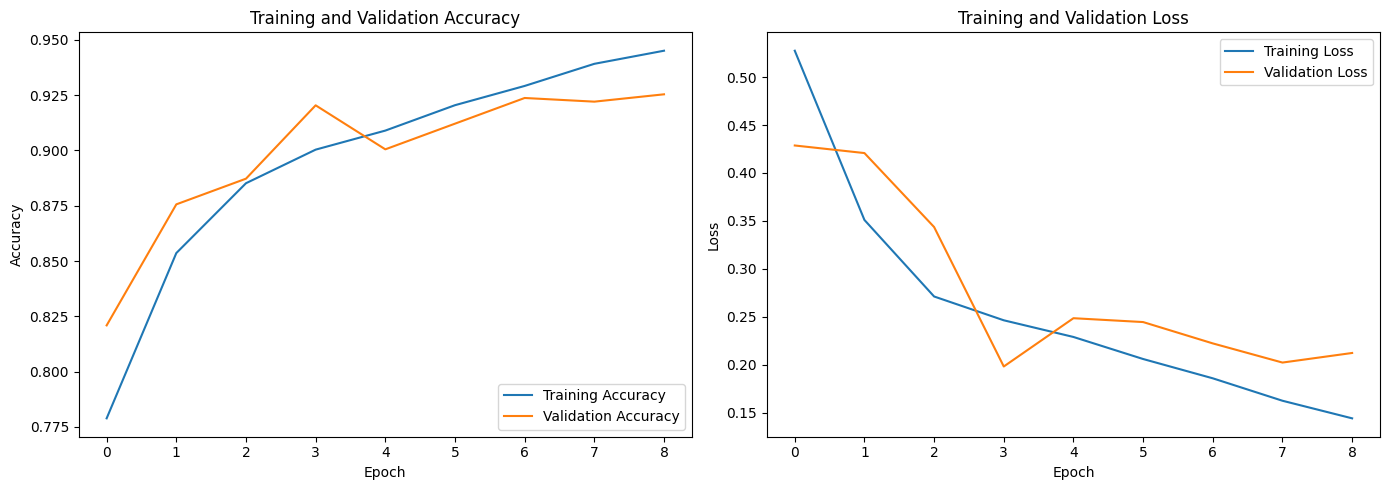

In [41]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.savefig("corn-leaf-image/akurasi_loss_plot.png")
plt.show()


In [45]:
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))



=== Classification Report ===
                          precision    recall  f1-score   support

        Corn__CommonRust       0.99      0.92      0.95       197
      Corn__GrayLeafSpot       0.78      0.79      0.79        87
           Corn__Healthy       1.00      0.99      0.99       175
Corn__NorthernLeafBlight       0.84      0.93      0.88       148

                accuracy                           0.92       607
               macro avg       0.90      0.91      0.90       607
            weighted avg       0.93      0.92      0.92       607



19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step


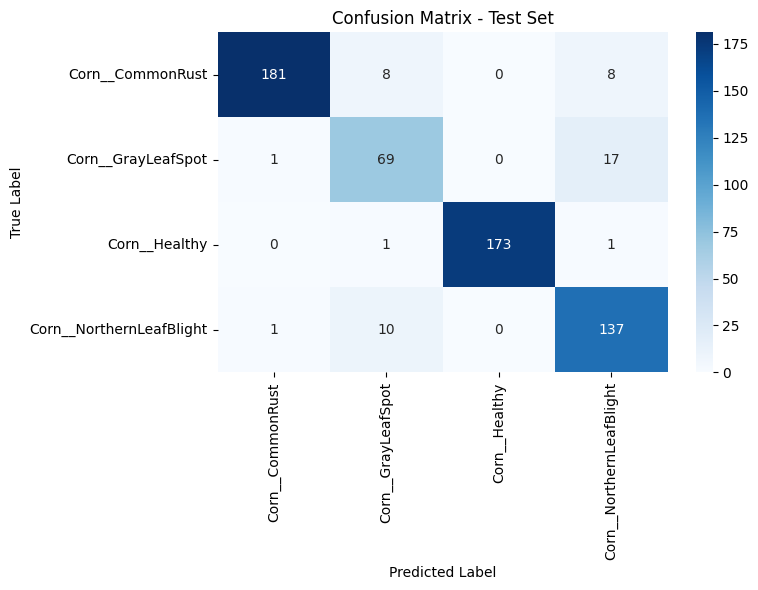

In [44]:
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()
y_true = test_generator.classes  # label asli sesuai urutan file di generator

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig("corn-leaf-image/confusion_matrix.png")
plt.show()

## Konversi Model

In [42]:
submission_dir = "submission"
os.makedirs(submission_dir, exist_ok=True)

# 11a. SavedModel -> submission/saved_model/
saved_model_dir = os.path.join(submission_dir, "saved_model")
model.export(saved_model_dir)
print("SavedModel disimpan di:", saved_model_dir)

# 11b. TF-Lite -> submission/tflite/
tflite_dir = os.path.join(submission_dir, "tflite")
os.makedirs(tflite_dir, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()

tflite_path = os.path.join(tflite_dir, "model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print("TF-Lite model disimpan di:", tflite_path)

# Label TF-Lite -> submission/tflite/label.txt
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
label_path = os.path.join(tflite_dir, "label.txt")
with open(label_path, "w") as f:
    for i in range(len(idx_to_class)):
        f.write(idx_to_class[i] + "\n")
print("Label disimpan di:", label_path)


tfjs_dir = os.path.join(submission_dir, "tfjs_model")
os.makedirs(tfjs_dir, exist_ok=True)
tfjs.converters.save_keras_model(model, tfjs_dir)
print("TFJS model disimpan di:", tfjs_dir)

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136635483289552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136635483291472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136635483290128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136632279843280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136632279844624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136632279844048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136632279845008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136632279844816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136632279845392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136632279845200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13663

TF-Lite model disimpan di: submission/tflite/model.tflite
Label disimpan di: submission/tflite/label.txt
failed to lookup keras version from the file,
    this is likely a weight only file
TFJS model disimpan di: submission/tfjs_model


## Inference (Optional)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



=== HASIL INFERENCE (TF-Lite) ===
Sample 1: Predicted=Corn__GrayLeafSpot (90.9%), Actual=Corn__CommonRust
Sample 2: Predicted=Corn__NorthernLeafBlight (99.2%), Actual=Corn__CommonRust
Sample 3: Predicted=Corn__GrayLeafSpot (59.7%), Actual=Corn__CommonRust
Sample 4: Predicted=Corn__NorthernLeafBlight (63.9%), Actual=Corn__CommonRust
Sample 5: Predicted=Corn__CommonRust (43.2%), Actual=Corn__CommonRust
Sample 6: Predicted=Corn__NorthernLeafBlight (100.0%), Actual=Corn__CommonRust


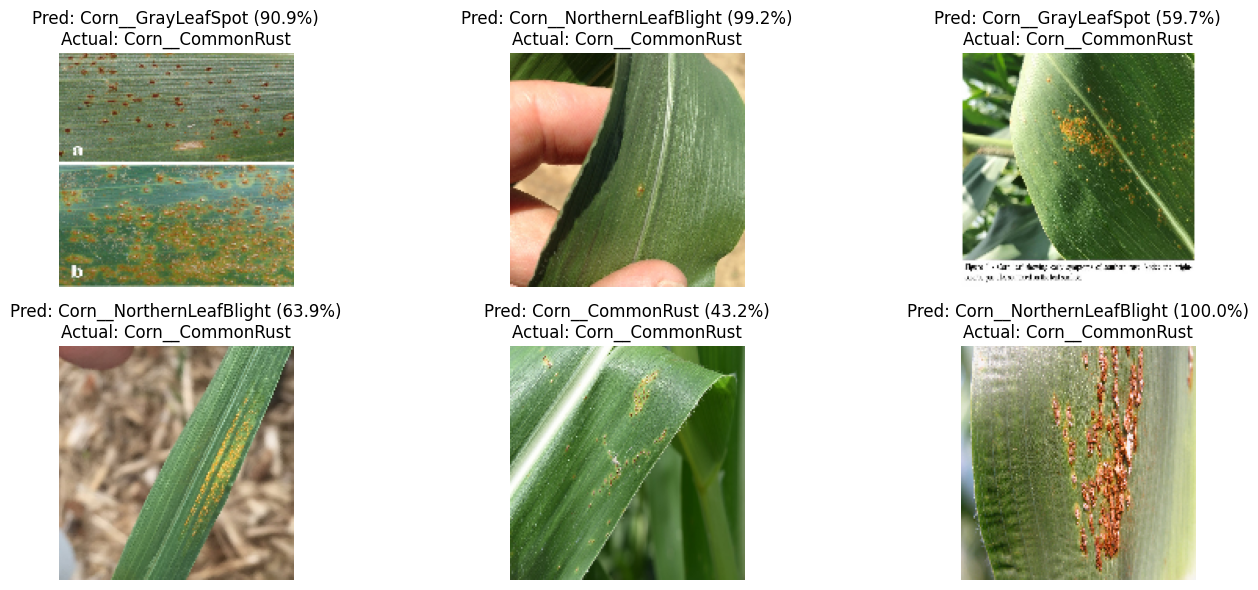

In [43]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

test_generator.reset()
sample_images, sample_labels = next(test_generator)

print("\n=== HASIL INFERENCE (TF-Lite) ===")
n_show = min(6, len(sample_images))
plt.figure(figsize=(15, 6))
for i in range(n_show):
    img = sample_images[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]["index"], img)
    interpreter.invoke()
    pred_probs = interpreter.get_tensor(output_details[0]["index"])[0]

    pred_idx = int(np.argmax(pred_probs))
    confidence = pred_probs[pred_idx]
    pred_class = idx_to_class[pred_idx]

    true_idx = int(np.argmax(sample_labels[i]))
    true_class = idx_to_class[true_idx]

    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"Pred: {pred_class} ({confidence*100:.1f}%)\nActual: {true_class}")
    plt.axis("off")

    print(f"Sample {i+1}: Predicted={pred_class} ({confidence*100:.1f}%), Actual={true_class}")

plt.tight_layout()
plt.savefig(os.path.join(submission_dir, "inference_result.png"))
plt.show()
